In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
df = pd.read_csv('/home/vivek/Documents/territory_geometry/processed_data/stability_ALL.csv')

# Standardise dates as years since first data point
df['date_now'] = pd.to_datetime(df['date_now'])
t0 = df['date_now'].min()
df['time_years'] = (df['date_now'] - t0).dt.days / 365.25

# Center and scale the time variable
time = df['time_years']
df['time_std'] = (time - time.mean()) / time.std()

df.head()

,lek_id,date_prev,date_now,centroid_shift,mode_shift,nn_cross_median,nn_cross_mean,nn_cross_cv,time_years,time_std
0,TalChhapar_TC,2012-10-01,2014-02-01,14.345197,25.195197,3.033985,6.864682,1.341986,0.000000,-1.453694
1,TalChhapar_TC,2014-02-01,2015-11-01,19.180344,44.531731,5.317716,9.612448,1.142450,1.746749,-0.912903
2,TalChhapar_TC,2015-11-01,2015-12-01,5.288125,33.362349,1.149035,4.630130,1.725009,1.828884,-0.887474
3,TalChhapar_TC,2015-12-01,2018-01-01,62.661803,27.941469,10.504549,24.557366,1.565752,3.915127,-0.241576
4,TalChhapar_TC,2018-01-01,2018-11-01,30.013742,65.168473,6.443491,12.524062,1.367217,4.747433,0.016105


In [3]:
# Encode lek ID as integers and assign plotting colors
df['lek_id_codes'] = df['lek_id'].astype('category').cat.codes + 1

leks = df['lek_id_codes'].unique()
colors = ['#367126', '#4545F5', '#D6604D'] 

In [4]:
crossyear_nnd = """
data {
    int<lower=1> N;               // total no. of observations
    int<lower=1> K;               // no. of leks
    array[N] int<lower=1, upper=K> lek;  // lek identity
    vector[N] t;                  // centred and scaled time
    vector<lower=0>[N] y;         // cross-year NND
}

parameters {
    real mu_alpha;                // population mean intercept (log-scale)
    real mu_beta;                 // population mean slope (log-scale)
    real<lower=0> sigma_alpha;    // variation among leks (intercepts)
    real<lower=0> sigma_beta;     // variation among leks (slopes)

    vector[K] alpha_raw;          // lek intercept deviations
    vector[K] beta_raw;           // lek slope deviations

    real<lower=0> phi;            // shape parameter
}

transformed parameters {
    vector[K] alpha = mu_alpha + sigma_alpha * alpha_raw;
    vector[K] beta  = mu_beta  + sigma_beta  * beta_raw;
    
    vector[N] mu = exp(alpha[lek] + beta[lek] .* t);
}

model {
    // priors
    alpha_raw ~ normal(0, 1);
    beta_raw  ~ normal(0, 1);

    mu_alpha ~ normal(0, 5);
    mu_beta  ~ normal(0, 5);
    sigma_alpha ~ exponential(1);
    sigma_beta  ~ exponential(1);
    phi ~ exponential(1);

    y ~ gamma(phi, phi / mu);
}
"""

data = {
    'N': len(df),
    'K': len(df.lek_id.unique()),
    'lek': df.lek_id_codes.to_numpy(),
    't': df.time_std.to_numpy(), 
    'y': df.nn_cross_median.to_numpy()
}

posterior = stan.build(crossyear_nnd, data=data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 3.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.38 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Inverse scale parameter[7] is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnw

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.


In [5]:
xmin = df['time_std'].min()
xmax = df['time_std'].max()

x_pred = np.linspace(xmin,xmax, 100)
t_pred = x_pred * time.std() + time.mean() 
t_pred = pd.to_datetime(t_pred*365.25, unit='D', origin=t0)

alpha = fit['alpha']
beta  = fit['beta']
phi = fit['phi'].reshape(-1)

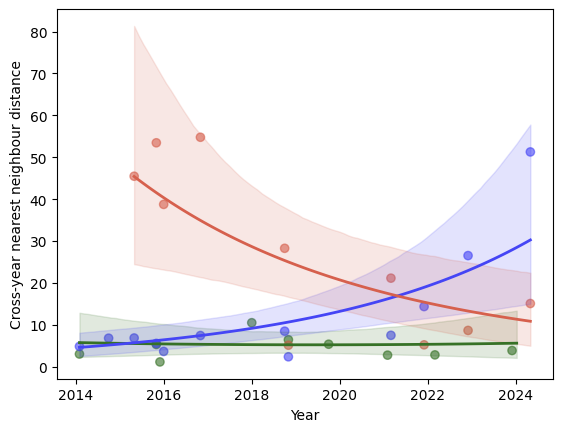

In [6]:
fig,ax = plt.subplots(1,1)

ax.scatter(df['date_now'], df['nn_cross_median'], c=df['lek_id_codes'].map(dict(zip(leks,colors))), alpha=0.6)

# posterior regression lines per lek
for lek_idx,col in zip(leks, colors):
    a = alpha[lek_idx-1,:]
    b = beta[lek_idx-1,:]
    
    y_pred = np.exp(a + b * x_pred[:,None])
    
    # restrict to observed time range for this lek
    t_min = df.loc[df['lek_id_codes'] == lek_idx, 'time_std'].min()
    t_max = df.loc[df['lek_id_codes'] == lek_idx, 'time_std'].max()
    mask = (x_pred >= 1.03*t_min) & (x_pred <= 1.03*t_max)
    
    ax.plot(t_pred[mask], y_pred.mean(axis=1)[mask], color=col, lw=2)
    ax.fill_between(t_pred[mask], np.quantile(y_pred, 0.025, axis=1)[mask], np.quantile(y_pred, 0.975, axis=1)[mask], color=col, alpha=0.15)

ax.set_xlabel("Year")
ax.set_ylabel("Cross-year nearest neighbour distance")
plt.show()

In [7]:
# observed data
y_obs = df['nn_cross_median'].values
t     = df['time_std'].values
lek   = df['lek_id_codes'].values - 1

# draw a subset of posterior samples
draw_idx = np.random.choice(alpha.shape[1], size=200, replace=False)

y_rep_all = []

for d in draw_idx:
    mu = np.exp(alpha[lek, d] + beta[lek, d] * t)
    y_rep = np.random.gamma(shape=phi[d], scale=mu / phi[d])
    y_rep_all.append(y_rep)

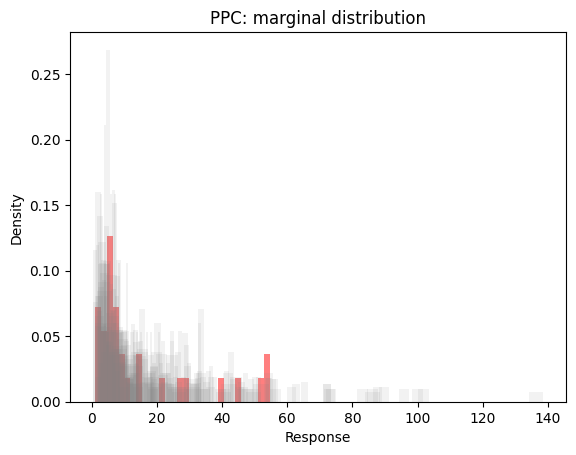

In [8]:
fig,ax = plt.subplots(1,1)

ax.hist(y_obs, bins=30, density=True, color='red', alpha=0.5, label='Observed')

for yrep in y_rep_all[::10]:
    ax.hist(yrep, bins=30, density=True, color='gray', alpha=0.1)
ax.set_xlabel("Response")
ax.set_ylabel("Density")
ax.set_title("PPC: marginal distribution")

plt.show()

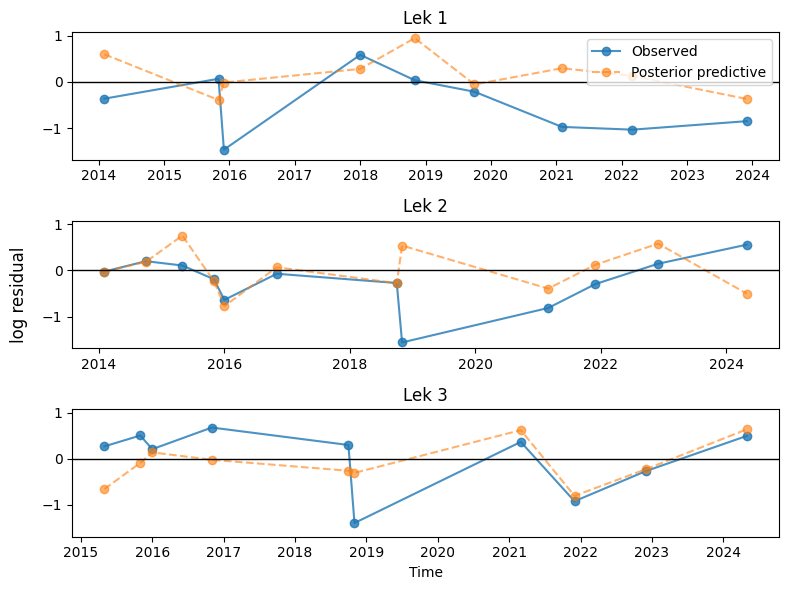

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# choose one posterior draw
d = np.random.choice(alpha.shape[1])

# model mean
mu_hat = np.exp(alpha[lek, d] + beta[lek, d] * t)

# observed log-residuals
r_obs = np.log(y_obs) - np.log(mu_hat)

# posterior predictive draw
y_rep = np.random.gamma(
    shape=phi[d],
    scale=mu_hat / phi[d]
)
r_rep = np.log(y_rep) - np.log(mu_hat)

# unique leks (already coded as 1,2,3 in your df)
leks_unique = np.sort(df["lek_id_codes"].unique())

fig, axes = plt.subplots(
    nrows=len(leks_unique),
    ncols=1,
    figsize=(8, 6),
    sharey=True,
    sharex=False
)

for ax, lek_id in zip(axes, leks_unique):

    mask = df["lek_id_codes"].values == lek_id

    ax.plot(
        df.loc[mask, "date_now"],
        r_obs[mask],
        "o-",
        label="Observed",
        alpha=0.8
    )

    ax.plot(
        df.loc[mask, "date_now"],
        r_rep[mask],
        "o--",
        label="Posterior predictive",
        alpha=0.6
    )

    ax.axhline(0, color="k", lw=1)
    ax.set_title(f"Lek {lek_id}")

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time")
fig.supylabel("log residual")

plt.tight_layout()
plt.show()

Observed max run lengths: {np.int8(1): 3, np.int8(2): 4, np.int8(3): 2}


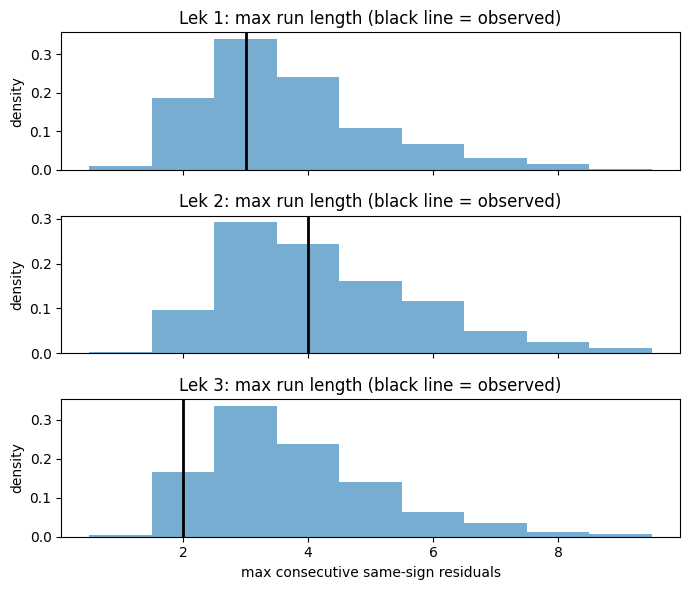

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def max_run_length_same_sign(x):
    """
    x: 1D array of residuals in time order
    returns: max length of consecutive residuals with same sign (ignores exact zeros)
    """
    s = np.sign(x)
    s = s[s != 0]
    if len(s) == 0:
        return 0

    max_run = 1
    run = 1
    for i in range(1, len(s)):
        if s[i] == s[i-1]:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 1
    return max_run


# ---- Observed statistic (using posterior mean mu) ----
# Use posterior mean of mu to define residuals robustly (not one random draw)
mu_mean = np.exp(alpha[lek, :].mean(axis=1) + beta[lek, :].mean(axis=1) * t)
r_obs = np.log(y_obs) - np.log(mu_mean)

leks_unique = np.sort(df["lek_id_codes"].unique())

obs_runs = {}
for lek_id in leks_unique:
    m = (df["lek_id_codes"].values == lek_id)
    # ensure time-ordered
    idx = np.argsort(df.loc[m, "date_now"].values)
    obs_runs[lek_id] = max_run_length_same_sign(r_obs[m][idx])

print("Observed max run lengths:", obs_runs)


# ---- Posterior predictive distribution of the statistic ----
draw_idx = np.random.choice(alpha.shape[1], size=500, replace=False)

rep_runs = {lek_id: [] for lek_id in leks_unique}

for d in draw_idx:
    mu = np.exp(alpha[lek, d] + beta[lek, d] * t)
    y_rep = np.random.gamma(shape=phi[d], scale=mu / phi[d])
    r_rep = np.log(y_rep) - np.log(mu)

    for lek_id in leks_unique:
        m = (df["lek_id_codes"].values == lek_id)
        idx = np.argsort(df.loc[m, "date_now"].values)
        rep_runs[lek_id].append(max_run_length_same_sign(r_rep[m][idx]))


# ---- Plot: PPC for run lengths ----
fig, axes = plt.subplots(len(leks_unique), 1, figsize=(7, 6), sharex=True)

for ax, lek_id in zip(axes, leks_unique):
    ax.hist(rep_runs[lek_id], bins=np.arange(0.5, 10.5, 1), density=True, alpha=0.6)
    ax.axvline(obs_runs[lek_id], color="k", lw=2)
    ax.set_title(f"Lek {lek_id}: max run length (black line = observed)")
    ax.set_ylabel("density")

axes[-1].set_xlabel("max consecutive same-sign residuals")
plt.tight_layout()
plt.show()

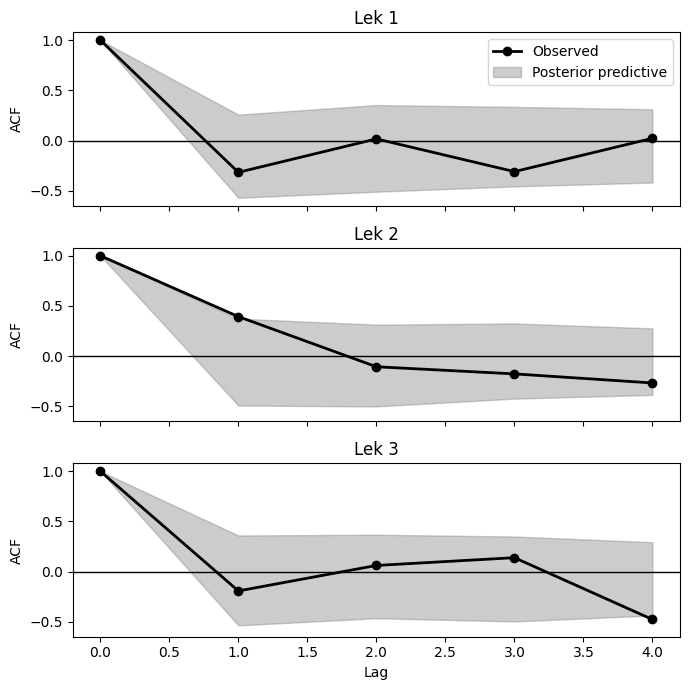

In [16]:
from statsmodels.tsa.stattools import acf

max_lag = 4
draw_idx = np.random.choice(alpha.shape[1], size=300, replace=False)

fig, axes = plt.subplots(len(leks_unique), 1, figsize=(7, 7), sharex=True, sharey=True)

for ax, lek_id in zip(axes, leks_unique):
    m = (df["lek_id_codes"].values == lek_id)
    idx = np.argsort(df.loc[m, "date_now"].values)

    # observed residuals using posterior mean mu
    r_obs_k = r_obs[m][idx]
    acf_obs = acf(r_obs_k, nlags=max_lag, fft=False)

    acf_rep = []
    for d in draw_idx:
        mu = np.exp(alpha[lek, d] + beta[lek, d] * t)
        y_rep = np.random.gamma(shape=phi[d], scale=mu / phi[d])
        r_rep = np.log(y_rep) - np.log(mu)

        r_rep_k = r_rep[m][idx]
        acf_rep.append(acf(r_rep_k, nlags=max_lag, fft=False))

    acf_rep = np.array(acf_rep)
    lags = np.arange(max_lag + 1)

    ax.plot(lags, acf_obs, "o-", color="black", lw=2, label="Observed")
    ax.fill_between(
        lags,
        np.percentile(acf_rep, 5, axis=0),
        np.percentile(acf_rep, 95, axis=0),
        color="gray",
        alpha=0.4,
        label="Posterior predictive"
    )
    ax.axhline(0, color="k", lw=1)
    ax.set_title(f"Lek {lek_id}")
    ax.set_ylabel("ACF")

axes[-1].set_xlabel("Lag")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

In [17]:
crossyear_nnd = """
data {
    int<lower=1> N;               // total no. of observations
    int<lower=1> K;               // no. of leks
    int<lower=1> T;               // number of unique years
    array[N] int<lower=1, upper=K> lek;  // lek identity
    array[N] int<lower=1, upper=T> year; // year index for each obs
    vector[N] t;                  // centred and scaled time
    vector<lower=0>[N] y;         // mode shift
}

parameters {
    real mu_alpha;                // population mean intercept (log-scale)
    real mu_beta;                 // population mean slope (log-scale)
    real<lower=0> sigma_alpha;    // variation among leks (intercepts)
    real<lower=0> sigma_beta;     // variation among leks (slopes)

    vector[K] alpha_raw;          // lek intercept deviations
    vector[K] beta_raw;           // lek slope deviations
    
    // slower latent time effect
    vector[T] delta;
    real<lower=0> sigma_delta;

    real<lower=0> phi;            // shape parameter
}

transformed parameters {
    vector[K] alpha = mu_alpha + sigma_alpha * alpha_raw;
    vector[K] beta  = mu_beta  + sigma_beta  * beta_raw;
    
    vector[N] mu = exp(alpha[lek] + beta[lek] .* t);
}

model {
    // priors
    alpha_raw ~ normal(0, 1);
    beta_raw  ~ normal(0, 1);

    mu_alpha ~ normal(0, 5);
    mu_beta  ~ normal(0, 5);
    sigma_alpha ~ exponential(1);
    sigma_beta  ~ exponential(1);
    phi ~ exponential(1);

    y ~ gamma(phi, phi / mu);
}
"""

data = {
    'N': len(df),
    'K': len(df.lek_id.unique()),
    'lek': df.lek_id_codes.to_numpy(),
    't': df.time_std.to_numpy(), 
    'y': df.mode_shift.to_numpy()
}

posterior = stan.build(crossyear_nnd, data=data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   9% (700/8000)
Sampling:  34% (2700/8000)
Sampling:  59% (4700/8000)
Sampling:  84% (6700/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 3.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.39 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to 

  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected be

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: gamma_lpdf: Shape parameter is 0, but must be positive finite! (in '/tmp/httpstan_pobqglt_/model_sl67fnwe.stan', line 40, column 4 to column 29)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matric

In [18]:
xmin = df['time_std'].min()
xmax = df['time_std'].max()

x_pred = np.linspace(xmin,xmax, 100)
t_pred = x_pred * time.std() + time.mean() 
t_pred = pd.to_datetime(t_pred*365.25, unit='D', origin=t0)

alpha = fit['alpha']
beta  = fit['beta']

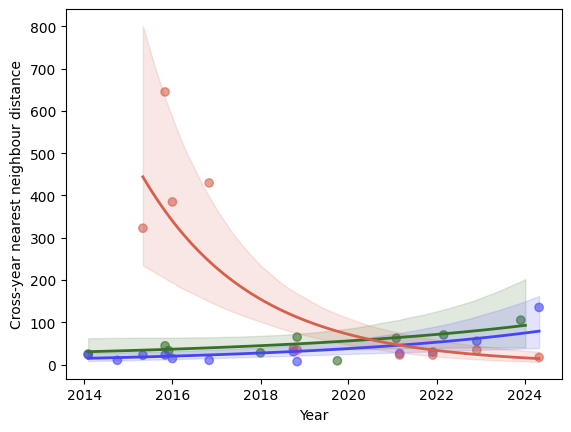

In [19]:
fig,ax = plt.subplots(1,1)

ax.scatter(df['date_now'], df['mode_shift'], c=df['lek_id_codes'].map(dict(zip(leks,colors))), alpha=0.6)

# posterior regression lines per lek
for lek_idx,col in zip(leks, colors):
    a = alpha[lek_idx-1,:]
    b = beta[lek_idx-1,:]
    
    y_pred = np.exp(a + b * x_pred[:,None])
    
    # restrict to observed time range for this lek
    t_min = df.loc[df['lek_id_codes'] == lek_idx, 'time_std'].min()
    t_max = df.loc[df['lek_id_codes'] == lek_idx, 'time_std'].max()
    mask = (x_pred >= 1.03*t_min) & (x_pred <= 1.03*t_max)
    
    ax.plot(t_pred[mask], y_pred.mean(axis=1)[mask], color=col, lw=2)
    ax.fill_between(t_pred[mask], np.quantile(y_pred, 0.025, axis=1)[mask], np.quantile(y_pred, 0.975, axis=1)[mask], color=col, alpha=0.15)

ax.set_xlabel("Year")
ax.set_ylabel("Cross-year nearest neighbour distance")
plt.show()

In [20]:
# observed data
y_obs = df['nn_cross_median'].values
t     = df['time_std'].values
lek   = df['lek_id_codes'].values - 1

# draw a subset of posterior samples
draw_idx = np.random.choice(alpha.shape[1], size=200, replace=False)

y_rep_all = []

for d in draw_idx:
    mu = np.exp(alpha[lek, d] + beta[lek, d] * t)
    y_rep = np.random.gamma(shape=phi[d], scale=mu / phi[d])
    y_rep_all.append(y_rep)

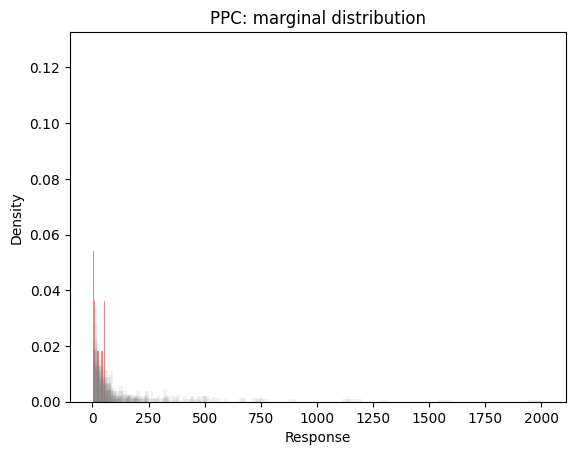

In [30]:
fig,ax = plt.subplots(1,1)

ax.hist(y_obs, bins=30, density=True, color='red', alpha=0.5, label='Observed')

for yrep in y_rep_all[::10]:
    ax.hist(yrep, bins=30, density=True, color='gray', alpha=0.1)
ax.set_xlabel("Response")
ax.set_ylabel("Density")
ax.set_title("PPC: marginal distribution")

plt.show()

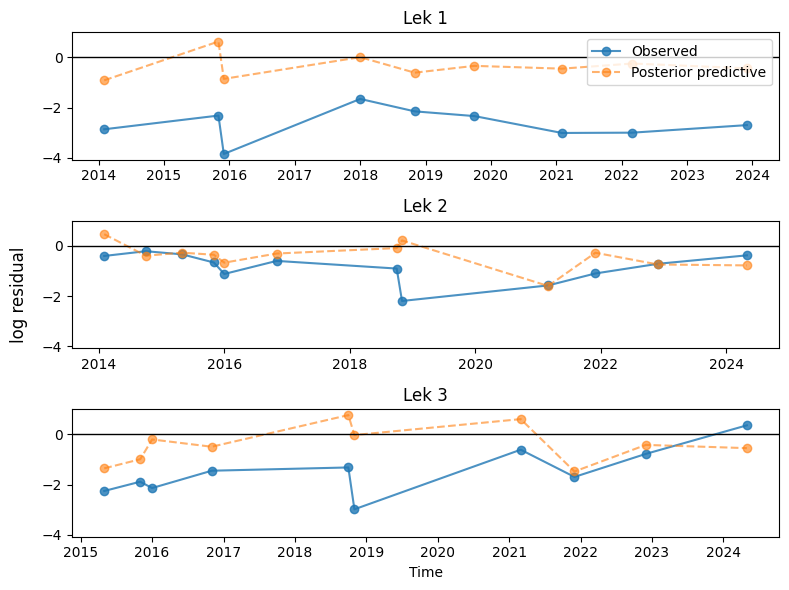

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# choose one posterior draw
d = np.random.choice(alpha.shape[1])

# model mean
mu_hat = np.exp(alpha[lek, d] + beta[lek, d] * t)

# observed log-residuals
r_obs = np.log(y_obs) - np.log(mu_hat)

# posterior predictive draw
y_rep = np.random.gamma(
    shape=phi[d],
    scale=mu_hat / phi[d]
)
r_rep = np.log(y_rep) - np.log(mu_hat)

# unique leks (already coded as 1,2,3 in your df)
leks_unique = np.sort(df["lek_id_codes"].unique())

fig, axes = plt.subplots(
    nrows=len(leks_unique),
    ncols=1,
    figsize=(8, 6),
    sharey=True,
    sharex=False
)

for ax, lek_id in zip(axes, leks_unique):

    mask = df["lek_id_codes"].values == lek_id

    ax.plot(
        df.loc[mask, "date_now"],
        r_obs[mask],
        "o-",
        label="Observed",
        alpha=0.8
    )

    ax.plot(
        df.loc[mask, "date_now"],
        r_rep[mask],
        "o--",
        label="Posterior predictive",
        alpha=0.6
    )

    ax.axhline(0, color="k", lw=1)
    ax.set_title(f"Lek {lek_id}")

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time")
fig.supylabel("log residual")

plt.tight_layout()
plt.show()

Observed max run lengths: {np.int8(1): 9, np.int8(2): 12, np.int8(3): 9}


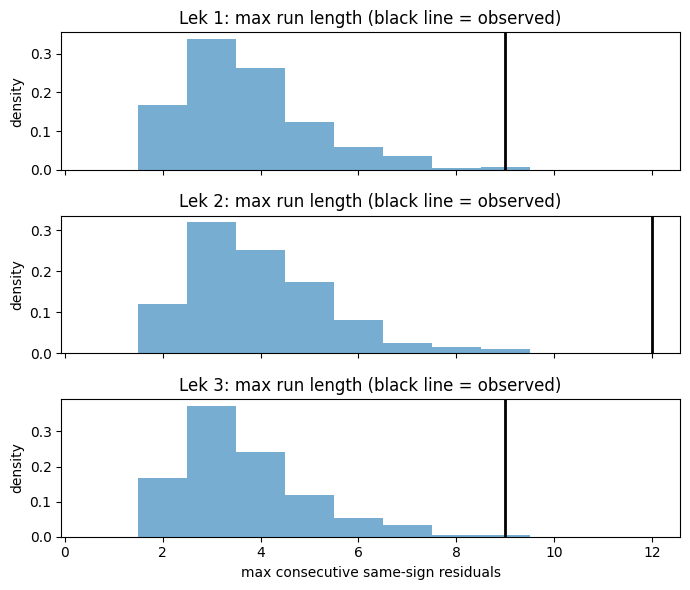

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def max_run_length_same_sign(x):
    """
    x: 1D array of residuals in time order
    returns: max length of consecutive residuals with same sign (ignores exact zeros)
    """
    s = np.sign(x)
    s = s[s != 0]
    if len(s) == 0:
        return 0

    max_run = 1
    run = 1
    for i in range(1, len(s)):
        if s[i] == s[i-1]:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 1
    return max_run


# ---- Observed statistic (using posterior mean mu) ----
# Use posterior mean of mu to define residuals robustly (not one random draw)
mu_mean = np.exp(alpha[lek, :].mean(axis=1) + beta[lek, :].mean(axis=1) * t)
r_obs = np.log(y_obs) - np.log(mu_mean)

leks_unique = np.sort(df["lek_id_codes"].unique())

obs_runs = {}
for lek_id in leks_unique:
    m = (df["lek_id_codes"].values == lek_id)
    # ensure time-ordered
    idx = np.argsort(df.loc[m, "date_now"].values)
    obs_runs[lek_id] = max_run_length_same_sign(r_obs[m][idx])

print("Observed max run lengths:", obs_runs)


# ---- Posterior predictive distribution of the statistic ----
draw_idx = np.random.choice(alpha.shape[1], size=500, replace=False)

rep_runs = {lek_id: [] for lek_id in leks_unique}

for d in draw_idx:
    mu = np.exp(alpha[lek, d] + beta[lek, d] * t)
    y_rep = np.random.gamma(shape=phi[d], scale=mu / phi[d])
    r_rep = np.log(y_rep) - np.log(mu)

    for lek_id in leks_unique:
        m = (df["lek_id_codes"].values == lek_id)
        idx = np.argsort(df.loc[m, "date_now"].values)
        rep_runs[lek_id].append(max_run_length_same_sign(r_rep[m][idx]))


# ---- Plot: PPC for run lengths ----
fig, axes = plt.subplots(len(leks_unique), 1, figsize=(7, 6), sharex=True)

for ax, lek_id in zip(axes, leks_unique):
    ax.hist(rep_runs[lek_id], bins=np.arange(0.5, 10.5, 1), density=True, alpha=0.6)
    ax.axvline(obs_runs[lek_id], color="k", lw=2)
    ax.set_title(f"Lek {lek_id}: max run length (black line = observed)")
    ax.set_ylabel("density")

axes[-1].set_xlabel("max consecutive same-sign residuals")
plt.tight_layout()
plt.show()

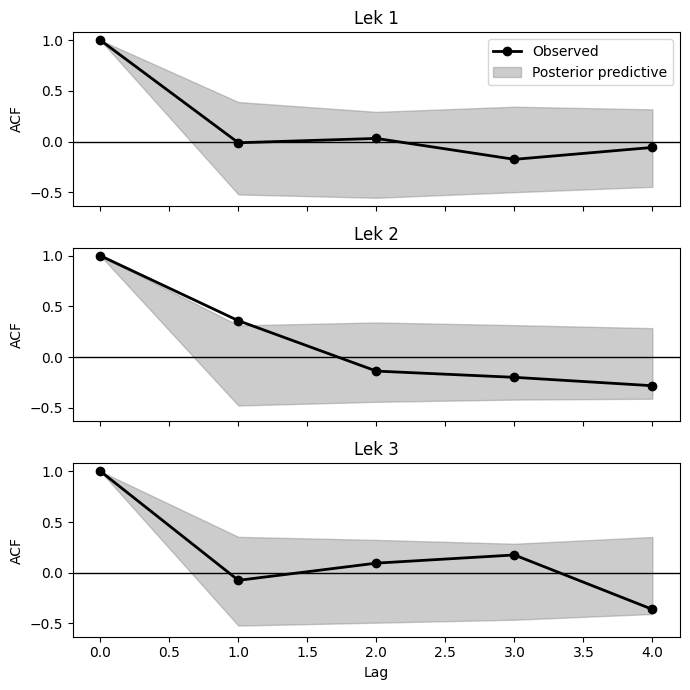

In [35]:
from statsmodels.tsa.stattools import acf

max_lag = 4
draw_idx = np.random.choice(alpha.shape[1], size=300, replace=False)

fig, axes = plt.subplots(len(leks_unique), 1, figsize=(7, 7), sharex=True, sharey=True)

for ax, lek_id in zip(axes, leks_unique):
    m = (df["lek_id_codes"].values == lek_id)
    idx = np.argsort(df.loc[m, "date_now"].values)

    # observed residuals using posterior mean mu
    r_obs_k = r_obs[m][idx]
    acf_obs = acf(r_obs_k, nlags=max_lag, fft=False)

    acf_rep = []
    for d in draw_idx:
        mu = np.exp(alpha[lek, d] + beta[lek, d] * t)
        y_rep = np.random.gamma(shape=phi[d], scale=mu / phi[d])
        r_rep = np.log(y_rep) - np.log(mu)

        r_rep_k = r_rep[m][idx]
        acf_rep.append(acf(r_rep_k, nlags=max_lag, fft=False))

    acf_rep = np.array(acf_rep)
    lags = np.arange(max_lag + 1)

    ax.plot(lags, acf_obs, "o-", color="black", lw=2, label="Observed")
    ax.fill_between(
        lags,
        np.percentile(acf_rep, 5, axis=0),
        np.percentile(acf_rep, 95, axis=0),
        color="gray",
        alpha=0.4,
        label="Posterior predictive"
    )
    ax.axhline(0, color="k", lw=1)
    ax.set_title(f"Lek {lek_id}")
    ax.set_ylabel("ACF")

axes[-1].set_xlabel("Lag")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()